# Bibliotecas utilizadas


In [1]:
import pandas as pd
import json
import requests
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# 📌 Extracão

In [2]:
# Extraindo dados da APi

url ='https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json' #Importante usar o link para o raw file

resposta = requests.get(url) 
dados_json = resposta.json()

df = pd.json_normalize(dados_json, sep ='_') # Normalizar dados_json para dados aninhados virarem colunas isoladas. usar seperador para visualizar nomes das colunas com '_' ao invés de '.'


             

In [3]:
df.head(10)

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
5,0013-MHZWF,No,Female,0,No,Yes,9,Yes,No,DSL,...,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),69.40,571.45
6,0013-SMEOE,No,Female,1,Yes,No,71,Yes,No,Fiber optic,...,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),109.70,7904.25
7,0014-BMAQU,No,Male,0,Yes,No,63,Yes,Yes,Fiber optic,...,No,No,Yes,No,No,Two year,Yes,Credit card (automatic),84.65,5377.8
8,0015-UOCOJ,No,Female,1,No,No,7,Yes,No,DSL,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,48.20,340.35
9,0016-QLJIS,No,Female,0,Yes,Yes,65,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Mailed check,90.45,5957.9


# 🔧 Transformação

## Conhecendo o dataset

In [4]:
# Verificando os tipos de dados no data frame

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [5]:
# Olhando os tipos de variáveis em cada coluna
# df.dtypes

## Verificando e tratando inconsitências nos dados

### Transformando account_Charges_Total em uma coluna numérica

In [6]:
# Transformando account_Charges_Total em uma coluna numérica
df['account_Charges_Total'] = df['account_Charges_Total'].apply(lambda x: x.replace(' ','0'))



df['account_Charges_Total'] = df['account_Charges_Total'].astype(np.float64)

In [7]:
df['account_Charges_Total'].dtypes

dtype('float64')

### Verificando itens duplicados

In [8]:
# Verificando duplicados
chaves = df.keys()

for i in range(0,21):
    a = df[chaves[i]].unique()
    print(a)


['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
['No' 'Yes' '']
['Female' 'Male']
[0 1]
['Yes' 'No']
['Yes' 'No']
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
['Yes' 'No']
['No' 'Yes' 'No phone service']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['One year' 'Month-to-month' 'Two year']
['Yes' 'No']
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
[65.6  59.9  73.9  ... 91.75 68.8  67.85]
[ 593.3   542.4   280.85 ...  742.9  4627.65 3707.6 ]


In [9]:
for i in chaves:
    # print(i)
    # print(len(df[i]))
    duplicados = df[i].unique()
    if len(duplicados) == 7267:
        print(i)

customerID


### verificando valores ausentes

In [10]:
# Verificando valores ausentes NaN

nulos_gerados = df.isna().sum()
nulos_gerados


customerID                   0
Churn                        0
customer_gender              0
customer_SeniorCitizen       0
customer_Partner             0
customer_Dependents          0
customer_tenure              0
phone_PhoneService           0
phone_MultipleLines          0
internet_InternetService     0
internet_OnlineSecurity      0
internet_OnlineBackup        0
internet_DeviceProtection    0
internet_TechSupport         0
internet_StreamingTV         0
internet_StreamingMovies     0
account_Contract             0
account_PaperlessBilling     0
account_PaymentMethod        0
account_Charges_Monthly      0
account_Charges_Total        0
dtype: int64

### Simplificando repostas

In [11]:
# simplificando respostas para 'no'
df = df.replace(['No internet service', 'No phone service'], 'no')

# print("Valores em phone_MultipleLines:", df['phone_MultipleLines'].unique())
# print("Valores em internet_OnlineSecurity:", df['internet_OnlineSecurity'].unique())

### Formatação em letras minúsculas

In [12]:
#formatando cabeçalho
df.columns = df.columns.str.lower()
df.columns


Index(['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total'],
      dtype='object')

In [13]:
# formatando respostas em minúsculo
colunas_texto = df.select_dtypes(include=['object']).columns

for coluna in colunas_texto:
    df[coluna] = df[coluna].str.lower()

df

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
0,0002-orfbo,no,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.60,593.30
1,0003-mknfe,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed check,59.90,542.40
2,0004-tlhlj,yes,male,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month-to-month,yes,electronic check,73.90,280.85
3,0011-igkff,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.00,1237.85
4,0013-exchz,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month-to-month,yes,mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-lutyd,no,female,0,no,no,13,yes,no,dsl,...,no,no,yes,no,no,one year,no,mailed check,55.15,742.90
7263,9992-rramn,yes,male,0,yes,no,22,yes,yes,fiber optic,...,no,no,no,no,yes,month-to-month,yes,electronic check,85.10,1873.70
7264,9992-ujoel,no,male,0,no,no,2,yes,no,dsl,...,yes,no,no,no,no,month-to-month,yes,mailed check,50.30,92.75
7265,9993-lhieb,no,male,0,yes,yes,67,yes,no,dsl,...,no,yes,yes,no,yes,two year,no,mailed check,67.85,4627.65


### Traduzindo para o portugues

In [14]:
dicionario_traducao = {
    'yes': 'sim',
    'no': 'não',
    'male': 'masculino',
    'female': 'feminino',
    'month-to-month': 'mensal',
    'one year': 'anual',
    'two year': 'dois anos',
    'electronic check': 'cheque eletrônico',
    'mailed check': 'cheque por correio',
    'bank transfer (automatic)': 'transferência bancária (automática)',
    'credit card (automatic)': 'cartão de crédito (automático)',
    'fiber optic': 'fibra ótica'
}

df = df.replace(dicionario_traducao)

df

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
0,0002-orfbo,não,feminino,0,sim,sim,9,sim,não,dsl,...,sim,não,sim,sim,não,anual,sim,cheque por correio,65.60,593.30
1,0003-mknfe,não,masculino,0,não,não,9,sim,sim,dsl,...,não,não,não,não,sim,mensal,não,cheque por correio,59.90,542.40
2,0004-tlhlj,sim,masculino,0,não,não,4,sim,não,fibra ótica,...,não,sim,não,não,não,mensal,sim,cheque eletrônico,73.90,280.85
3,0011-igkff,sim,masculino,1,sim,não,13,sim,não,fibra ótica,...,sim,sim,não,sim,sim,mensal,sim,cheque eletrônico,98.00,1237.85
4,0013-exchz,sim,feminino,1,sim,não,3,sim,não,fibra ótica,...,não,não,sim,sim,não,mensal,sim,cheque por correio,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-lutyd,não,feminino,0,não,não,13,sim,não,dsl,...,não,não,sim,não,não,anual,não,cheque por correio,55.15,742.90
7263,9992-rramn,sim,masculino,0,sim,não,22,sim,sim,fibra ótica,...,não,não,não,não,sim,mensal,sim,cheque eletrônico,85.10,1873.70
7264,9992-ujoel,não,masculino,0,não,não,2,sim,não,dsl,...,sim,não,não,não,não,mensal,sim,cheque por correio,50.30,92.75
7265,9993-lhieb,não,masculino,0,sim,sim,67,sim,não,dsl,...,não,sim,sim,não,sim,dois anos,não,cheque por correio,67.85,4627.65


### Transformando Sim e Não em binários

In [15]:
map_bin = {
    'sim': 1,
    'não': 0
}

df = df.replace(map_bin)

df


C:\Users\Otavio\AppData\Local\Temp\ipykernel_1208\1850693792.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(map_bin)


,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
0,0002-orfbo,0,feminino,0,1,1,9,1,0,dsl,...,1,0,1,1,0,anual,1,cheque por correio,65.60,593.30
1,0003-mknfe,0,masculino,0,0,0,9,1,1,dsl,...,0,0,0,0,1,mensal,0,cheque por correio,59.90,542.40
2,0004-tlhlj,1,masculino,0,0,0,4,1,0,fibra ótica,...,0,1,0,0,0,mensal,1,cheque eletrônico,73.90,280.85
3,0011-igkff,1,masculino,1,1,0,13,1,0,fibra ótica,...,1,1,0,1,1,mensal,1,cheque eletrônico,98.00,1237.85
4,0013-exchz,1,feminino,1,1,0,3,1,0,fibra ótica,...,0,0,1,1,0,mensal,1,cheque por correio,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-lutyd,0,feminino,0,0,0,13,1,0,dsl,...,0,0,1,0,0,anual,0,cheque por correio,55.15,742.90
7263,9992-rramn,1,masculino,0,1,0,22,1,1,fibra ótica,...,0,0,0,0,1,mensal,1,cheque eletrônico,85.10,1873.70
7264,9992-ujoel,0,masculino,0,0,0,2,1,0,dsl,...,1,0,0,0,0,mensal,1,cheque por correio,50.30,92.75
7265,9993-lhieb,0,masculino,0,1,1,67,1,0,dsl,...,0,1,1,0,1,dois anos,0,cheque por correio,67.85,4627.65


### Removendo a coluna de ID

In [16]:
df.pop('customerid')
df

,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
0,0,feminino,0,1,1,9,1,0,dsl,0,1,0,1,1,0,anual,1,cheque por correio,65.60,593.30
1,0,masculino,0,0,0,9,1,1,dsl,0,0,0,0,0,1,mensal,0,cheque por correio,59.90,542.40
2,1,masculino,0,0,0,4,1,0,fibra ótica,0,0,1,0,0,0,mensal,1,cheque eletrônico,73.90,280.85
3,1,masculino,1,1,0,13,1,0,fibra ótica,0,1,1,0,1,1,mensal,1,cheque eletrônico,98.00,1237.85
4,1,feminino,1,1,0,3,1,0,fibra ótica,0,0,0,1,1,0,mensal,1,cheque por correio,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,feminino,0,0,0,13,1,0,dsl,1,0,0,1,0,0,anual,0,cheque por correio,55.15,742.90
7263,1,masculino,0,1,0,22,1,1,fibra ótica,0,0,0,0,0,1,mensal,1,cheque eletrônico,85.10,1873.70
7264,0,masculino,0,0,0,2,1,0,dsl,0,1,0,0,0,0,mensal,1,cheque por correio,50.30,92.75
7265,0,masculino,0,1,1,67,1,0,dsl,1,0,1,1,0,1,dois anos,0,cheque por correio,67.85,4627.65


### Tratando espaços " " em churn

In [17]:


vazios_churn = (df['churn'] == '').sum() # contar quantos espaços vazios temos
vazios_churn


df['churn'] = df['churn'].replace('', np.nan) #substituir por nan


df = df.dropna(subset=['churn'])#apagar linhas com churn nan


df['churn'] = df['churn'].astype(int)# garantir que churn ainda é do type int


df['churn'].unique() # verificar quantos valores distintos temos como resposta

C:\Users\Otavio\AppData\Local\Temp\ipykernel_1208\2761397565.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['churn'] = df['churn'].replace('', np.nan) #substituir por nan
C:\Users\Otavio\AppData\Local\Temp\ipykernel_1208\2761397565.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['churn'] = df['churn'].astype(int)# garantir que churn ainda é do type int


array([0, 1])

# 📊 Carga e análise

## Describe para numéricos e não numéricos

In [18]:
df.describe()

,churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_paperlessbilling,account_charges_monthly,account_charges_total
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2279.734304
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2266.794470
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,398.550000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1394.550000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000


In [19]:
df.describe(include=['object'])

,customer_gender,internet_internetservice,account_contract,account_paymentmethod
count,7043,7043,7043,7043
unique,2,3,3,4
top,masculino,fibra ótica,mensal,cheque eletrônico
freq,3555,3096,3875,2365


## Evasão

Quantidade de clientes por status de Churn:
churn
0    5174
1    1869
Name: count, dtype: int64


C:\Users\Otavio\AppData\Local\Temp\ipykernel_1208\710325746.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='churn', ax=axes[0], palette=['#2ecc71', '#e74c3c'])


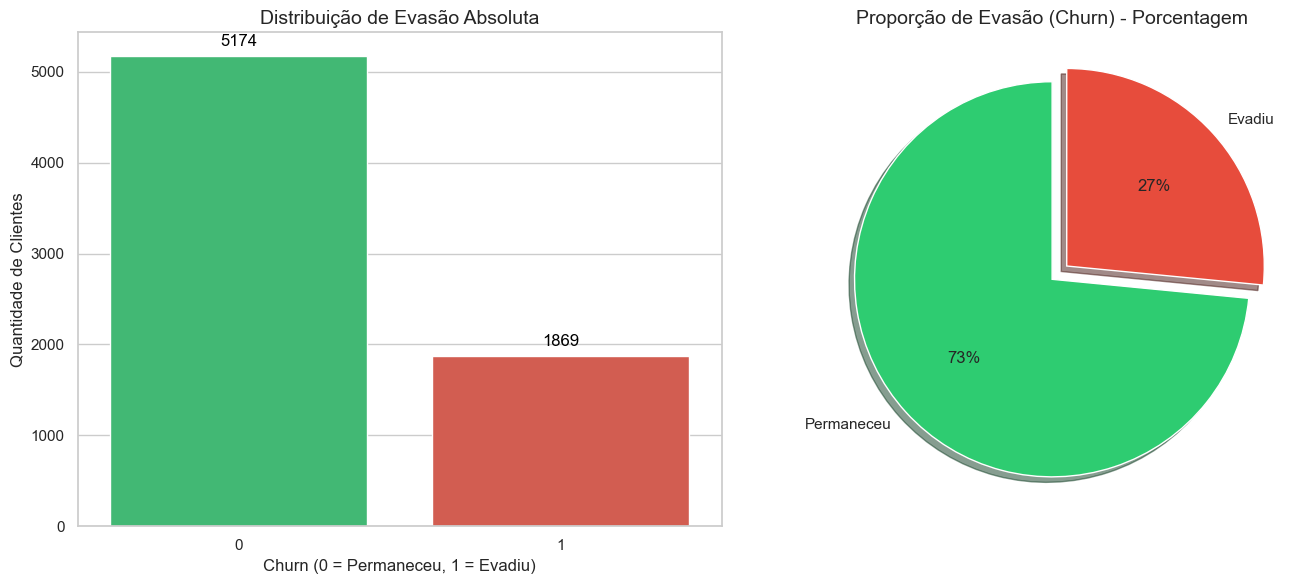

In [20]:
# 1. Contar a quantidade de clientes que evadiram (1) e que permaneceram (0)

contagem_churn = df['churn'].value_counts()
print("Quantidade de clientes por status de Churn:")
print(contagem_churn)

# 2. Configurar o estilo dos gráficos e o tamanho da figura
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Gráfico de Barras (Quantidade Absoluta)
sns.countplot(data=df, x='churn', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribuição de Evasão Absoluta', fontsize=14)
axes[0].set_xlabel('Churn (0 = Permaneceu, 1 = Evadiu)', fontsize=12)
axes[0].set_ylabel('Quantidade de Clientes', fontsize=12)

# Adicionando os rótulos de dados em cima das barras
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')

# Gráfico 2: Gráfico de Pizza (Proporção em %)
axes[1].pie(contagem_churn, labels=['Permaneceu', 'Evadiu'], autopct='%1.0f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.1), shadow=True)
axes[1].set_title('Proporção de Evasão (Churn) - Porcentagem', fontsize=14)

# Ajustar o layout e exibir
plt.tight_layout()
plt.show()

## Distribuição da Evasão por categoria


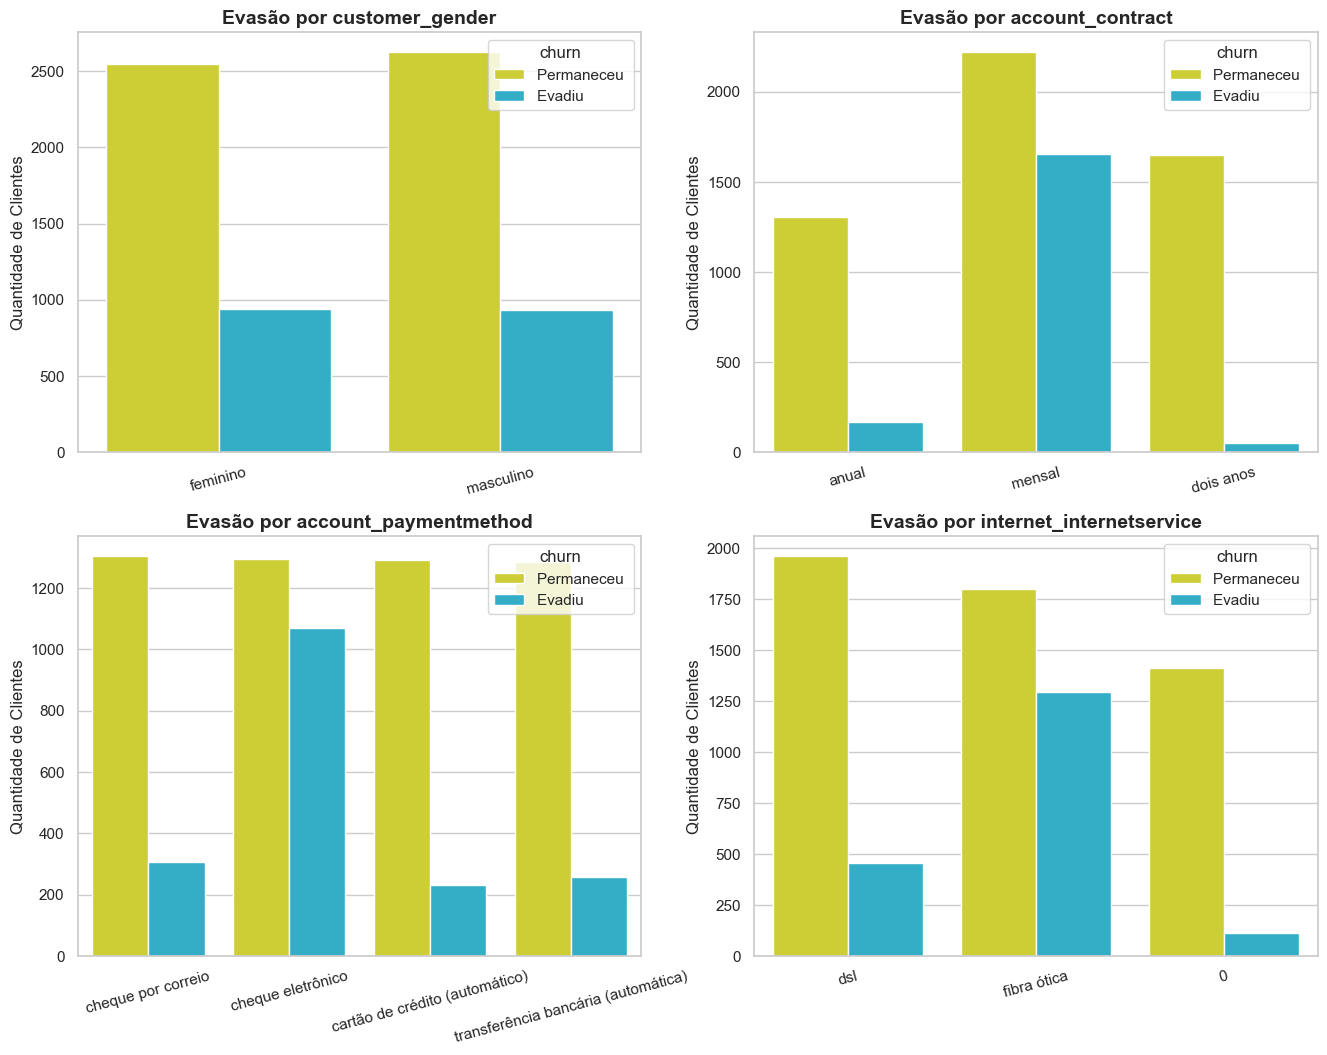

In [21]:
colunas_analise = ['customer_gender', 'account_contract', 'account_paymentmethod', 'internet_internetservice'] # definir colunas de interesse para investigar

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")


axes = axes.flatten() # facilitar o loop

for i, coluna in enumerate(colunas_analise):
    sns.countplot(data=df, x=coluna, hue='churn', ax=axes[i], palette=["#e6e61d", "#1abedf"])
    
    # Ajustes estéticos
    axes[i].set_title(f'Evasão por {coluna}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Quantidade de Clientes')
    axes[i].tick_params(axis='x', rotation=15) # Rotacionar os nomes no eixo X para não encavalar
    axes[i].legend(title='churn', labels=['Permaneceu ', 'Evadiu '])


## Distribuição de evasão numérica

C:\Users\Otavio\AppData\Local\Temp\ipykernel_1208\672414920.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y=coluna, ax=axes[i], palette=["#5a56dd", "#d05ea6"])
C:\Users\Otavio\AppData\Local\Temp\ipykernel_1208\672414920.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y=coluna, ax=axes[i], palette=["#5a56dd", "#d05ea6"])
C:\Users\Otavio\AppData\Local\Temp\ipykernel_1208\672414920.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y=coluna, ax=axes[i], palette=["#5a56dd"

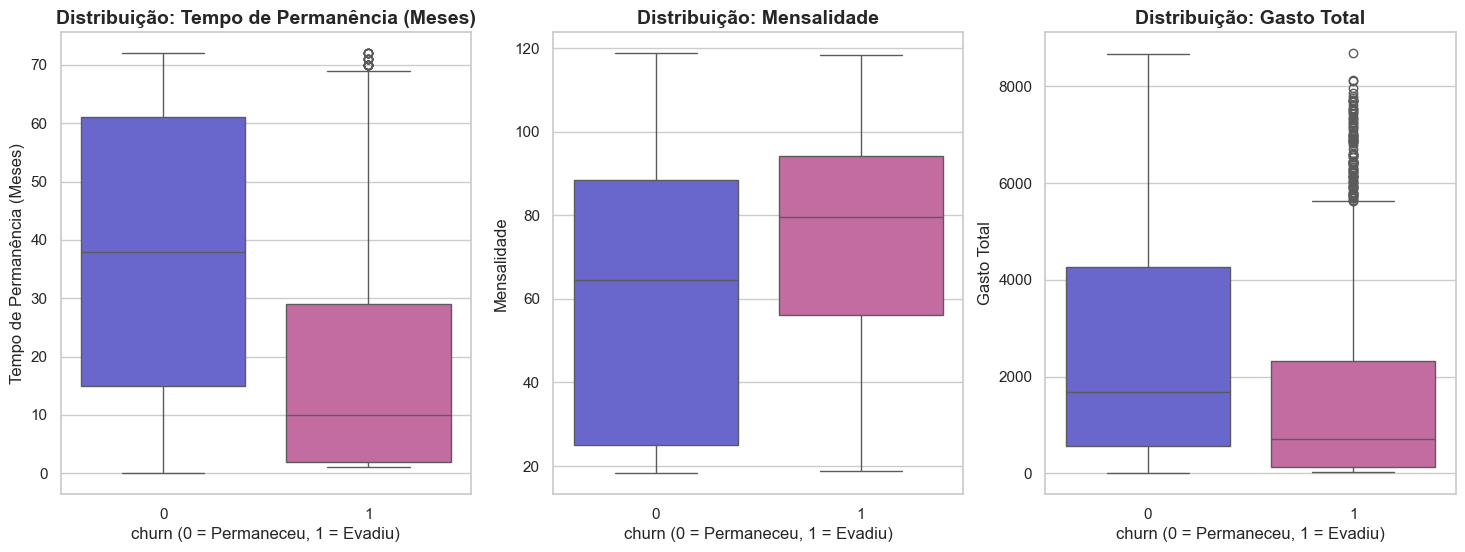

In [22]:


# Definir as variáveis numéricas para análise
colunas_numericas = ['customer_tenure', 'account_charges_monthly', 'account_charges_total']
titulos = ['Tempo de Permanência (Meses)', 'Mensalidade', 'Gasto Total']

# Configurar a área do gráfico 1 linha, 3 colunas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.set_theme(style="whitegrid")

# gerar um Boxplot para cada variável numérica
for i, coluna in enumerate(colunas_numericas):
    sns.boxplot(data=df, x='churn', y=coluna, ax=axes[i], palette=["#5a56dd", "#d05ea6"])
    
    
    axes[i].set_title(f'Distribuição: {titulos[i]}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('churn (0 = Permaneceu, 1 = Evadiu)', fontsize=12)
    axes[i].set_ylabel(titulos[i], fontsize=12)



# 📄Relatorio Final

**Introdução**

Nesse relatório detalharemos uma análise de dados da companhia TelecomX com intuito de entender o recente problema de altas taxas de evasão dos clientes. Para tal utilizaremos a prática do ETL, onde extrairemos a fonte de dados, Transformaremos eles para melhor leitura e interpretação e em seguida carregaremos os dados na nossa base dados para posteriores análises, incluindo gráficos e outros elementos que orientarão a solução para nossos problemas.

**Limpeza e tratamento de dados**

Para extração dos dados contamos com uso de bibliotecas como request, pandas e json. Houve um tratamento prévio dos dados uma vez que as estruturas aninhadas poderiam complicar a visualização e entendimento do dataset. Em seguida se deu início ao tratamento de dados mais intensivo. Nessa fase do projeto padronizamos todos os dados para serem exibidos em letras minúsculas habilitando futuramente a opção de tokenização dos dados. Também realizamos uma varredura completa nas colunas do nosso dataset, verificando a duplicidade de dados, a presença de dados nulos ou em branco e tratando-os quando necessário. Para melhor leitura e uso da tabela optamos por excluir a coluna de IDs, bem como as linhas que não estavam preenchidas quanto a permanência ou evasão de determinado cliente, evitando o enviesamento de nossa análise. Por praticidade, as respostas para algumas questões dados em no formato 'sim' ou 'não' foram transformadas em binário, facilitando a análise prévia que seria realizada posteriormente.

**Carga e Análise dos dados**

Das análise prévias obteve-se as seguintes conclusões: 

* Identificou-se que cerca de 27% da base de clientes analisada evadiu, configurando uma taxa de cancelamento alarmante.

* Variáveis Categóricas: A análise por categorias demonstrou que o gênero não influencia no cancelamento. Por outro lado, o tipo de contrato tem um impacto massivo: a esmagadora maioria das evasões ocorre em contratos da modalidade Mensal. O método de pagamento via Cheque Eletrônico e o serviço de internet via Fibra Ótica também concentram altas taxas de perda de clientes.

* Variáveis Numéricas: Os gráficos de distribuição (Boxplots) confirmaram que a evasão é extremamente alta nos primeiros meses de assinatura (baixo tempo de permanência). Além disso, clientes que evadem tendem a pagar mensalidades mais altas em comparação aos que permanecem. O gasto total é maior entre os clientes retidos, o que é uma consequência natural da longevidade do contrato.

**Conclusões e Insights**

Assim concluíse que o cliente com maior probabilidade de evasão possui as seguintes características: 

1. É um cliente recente (cancela nos primeiros meses).
2. Possui contrato mensal (sem barreiras ou multas de saída).
3. Contratou internet de Fibra Ótica, o que gera uma mensalidade mais alta.
4 .Paga de forma manual (cheque eletrônico), o que gera atrito e o faz lembrar constantemente do custo do serviço.


**Recomendações Estratégicas**

Sugerimos as seguintes ações para a equipe de negócios da Telecom X:

* Incentivo a Contratos Longos: Criar benefícios adicionais para incentivar a migração de clientes do plano mensal para os planos de um ou dois anos.

* Revisão do Produto "Fibra Ótica": Investigar o serviço de Fibra Ótica. A alta evasão aliada às altas mensalidades indica que o cliente não está enxergando valor no serviço.

* Estímulo ao Pagamento Automático: Oferecer pequenos descontos na fatura para clientes que cadastrarem o pagamento em débito automático ou cartão de crédito.



# Exportando os dados para CSV

In [24]:
df.to_csv('TelecomX_Dados_Tratados.csv', index=False)


dd = pd.read_csv('TelecomX_Dados_Tratados.csv')
dd

,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
0,0,feminino,0,1,1,9,1,0,dsl,0,1,0,1,1,0,anual,1,cheque por correio,65.60,593.30
1,0,masculino,0,0,0,9,1,1,dsl,0,0,0,0,0,1,mensal,0,cheque por correio,59.90,542.40
2,1,masculino,0,0,0,4,1,0,fibra ótica,0,0,1,0,0,0,mensal,1,cheque eletrônico,73.90,280.85
3,1,masculino,1,1,0,13,1,0,fibra ótica,0,1,1,0,1,1,mensal,1,cheque eletrônico,98.00,1237.85
4,1,feminino,1,1,0,3,1,0,fibra ótica,0,0,0,1,1,0,mensal,1,cheque por correio,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,feminino,0,0,0,13,1,0,dsl,1,0,0,1,0,0,anual,0,cheque por correio,55.15,742.90
7039,1,masculino,0,1,0,22,1,1,fibra ótica,0,0,0,0,0,1,mensal,1,cheque eletrônico,85.10,1873.70
7040,0,masculino,0,0,0,2,1,0,dsl,0,1,0,0,0,0,mensal,1,cheque por correio,50.30,92.75
7041,0,masculino,0,1,1,67,1,0,dsl,1,0,1,1,0,1,dois anos,0,cheque por correio,67.85,4627.65
